# Pipeline final de análise espectral

Este notebook organiza o fluxo metodológico completo do projeto. Nesta versão, são executadas as etapas já consolidadas: **aquisição dos dados**, **pré-processamento espectral**, **teste de normalidade**, **teste de diferenças significativas**, **redução de colinearidade**, **seleção de variáveis** e **classificação**. A análise temporal e o desenvolvimento do novo índice espectral permanecem como placeholders para integração futura.

Configuração estatística consolidada: espectro normalizado por SNV, leituras individuais, turno da manhã e parâmetros definidos nos módulos originais.

In [1]:
from __future__ import annotations

import io
import os
import runpy
import shutil
import sys
import time
from contextlib import redirect_stderr, redirect_stdout
from pathlib import Path
from unittest.mock import patch

import pandas as pd
from IPython.display import Image, display


def localizar_raiz(inicio: Path | None = None) -> Path:
    inicio = (inicio or Path.cwd()).resolve()
    for candidato in (inicio, *inicio.parents):
        if (candidato / "dataset").is_dir() and (candidato / "preprocessamento_espectral").is_dir():
            return candidato
    raise FileNotFoundError("Não foi possível localizar a raiz de EstresseHidricoFinal.")


ROOT = localizar_raiz()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
CLASSIFICACAO_DIR = ROOT / "classificacao"
if str(CLASSIFICACAO_DIR) not in sys.path:
    sys.path.insert(0, str(CLASSIFICACAO_DIR))

import classificacao as classificacao_pipeline
from dataset import limpar_metadados
from preprocessamento_espectral import normalizacao, preprocessamento, suavizacao
from reducaoColinearidade import reducao_colinearidade
from selecaoVariaveis.scripts import selecao_variaveis
from testeDeNormalidade import shapiro_normalidade
from testeDiferencaSignificativa.scripts import (
    diferencas_significativas,
    plot_heatmap_tukey_genotipos,
    plot_heatmaps_anova_tukey_completo,
)
from dispersoes import plot_preprocessamento, plot_preprocessamento_genotipo

LOGS: dict[str, str] = {}


def executar(etapa: str, funcao, *argumentos: str) -> None:
    captura = io.StringIO()
    inicio = time.perf_counter()
    argv = [f"{funcao.__module__}.py", *argumentos]
    with patch.object(sys, "argv", argv), redirect_stdout(captura), redirect_stderr(captura):
        funcao()
    LOGS[etapa] = captura.getvalue()
    print(f"✓ {etapa} concluída em {time.perf_counter() - inicio:.1f} s")


print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: C:\Vitor\SENAI\EstressFinal\EstresseHidricoFinal


## 1. Aquisição dos dados espectrais

Carregamento da base unificada e aplicação das correções consolidadas de metadados, sem alterar as leituras espectrais.

In [2]:
executar("Aquisição e limpeza dos dados", limpar_metadados.main)

✓ Aquisição e limpeza dos dados concluída em 7.6 s


In [3]:
dados_adquiridos = pd.read_csv(limpar_metadados.SAIDA, sep=";", decimal=",")
dados_adquiridos.columns = dados_adquiridos.columns.str.strip()
metadados = [coluna for coluna in dados_adquiridos.columns if not coluna.isdigit()]
bandas = sorted(int(coluna) for coluna in dados_adquiridos.columns if coluna.isdigit())

resumo_aquisicao = pd.DataFrame({
    "métrica": [
        "amostras", "metadados", "bandas espectrais", "faixa espectral",
        "valores ausentes", "linhas duplicadas", "genótipos", "condições",
    ],
    "valor": [
        len(dados_adquiridos), len(metadados), len(bandas), f"{bandas[0]}–{bandas[-1]} nm",
        int(dados_adquiridos.isna().sum().sum()), int(dados_adquiridos.duplicated().sum()),
        ", ".join(sorted(dados_adquiridos["genotipo"].dropna().astype(str).unique())),
        ", ".join(sorted(dados_adquiridos["condicao"].dropna().astype(str).unique())),
    ],
})
display(resumo_aquisicao)
del dados_adquiridos

,métrica,valor
0,amostras,1924
1,metadados,6
2,bandas espectrais,2151
3,faixa espectral,350–2500 nm
4,valores ausentes,0
5,linhas duplicadas,0
6,genótipos,"BR16, CD202, EMB48"
7,condições,"IRRIG, NIRRIG"


## 2. Correções e pré-processamento espectral

Execução sequencial de correção das emendas dos detectores, limpeza e interpolação, recorte para 400–2450 nm, suavização Savitzky–Golay e normalização SNV.

In [4]:
executar("Correção, limpeza e recorte espectral", preprocessamento.main)
executar("Suavização Savitzky–Golay", suavizacao.main)
executar("Normalização SNV", normalizacao.main)

✓ Correção, limpeza e recorte espectral concluída em 7.5 s


✓ Suavização Savitzky–Golay concluída em 7.3 s


✓ Normalização SNV concluída em 6.9 s


In [5]:
arquivos_preprocessamento = {
    "corrigido e recortado": preprocessamento.SAIDA,
    "suavizado": suavizacao.SAIDA,
    "normalizado (SNV)": normalizacao.SAIDA,
}

linhas_resumo = []
for estagio, arquivo in arquivos_preprocessamento.items():
    dados_estagio = pd.read_csv(arquivo, sep=";", decimal=",")
    bandas_estagio = sorted(int(c) for c in dados_estagio.columns if c.isdigit())
    linhas_resumo.append({
        "estágio": estagio,
        "amostras": len(dados_estagio),
        "bandas": len(bandas_estagio),
        "faixa_nm": f"{bandas_estagio[0]}–{bandas_estagio[-1]}",
        "ausentes": int(dados_estagio.isna().sum().sum()),
        "arquivo": arquivo.name,
    })
    del dados_estagio

resumo_preprocessamento = pd.DataFrame(linhas_resumo)
display(resumo_preprocessamento)

,estágio,amostras,bandas,faixa_nm,ausentes,arquivo
0,corrigido e recortado,1924,2051,400–2450,0,Unificada13052026_400_2450.csv
1,suavizado,1924,2051,400–2450,0,Unificada13052026_suavizado.csv
2,normalizado (SNV),1924,2051,400–2450,0,Unificada13052026_normalizado.csv


## 3. Teste de normalidade

Shapiro–Wilk por banda sobre o espectro normalizado, com correção FDR de Benjamini–Hochberg e agrupamentos por genótipo, condição e dia. Unidade estatística: leitura individual; turno: manhã.

In [6]:
executar("Teste de normalidade", shapiro_normalidade.main, "normalizado", "leitura")

✓ Teste de normalidade concluída em 29.3 s


In [7]:
normalidade = pd.read_csv(
    shapiro_normalidade.SAIDA_DIR / "normalidade_resumo.csv", sep=";"
)
normalidade_bandas = pd.read_csv(
    shapiro_normalidade.SAIDA_DIR / "normalidade_por_banda.csv", sep=";"
)

resumo_normalidade = (
    normalidade.groupby("agrupamento", as_index=False)
    .agg(
        grupos=("grupo", "size"),
        n_mínimo=("n_amostras", "min"),
        n_máximo=("n_amostras", "max"),
        proporção_normal_FDR_média=("prop_normais_q", "mean"),
        W_mediano=("W_mediano", "median"),
    )
)
resumo_normalidade[["proporção_normal_FDR_média", "W_mediano"]] = (
    resumo_normalidade[["proporção_normal_FDR_média", "W_mediano"]].round(3)
)
display(resumo_normalidade)

bandas_normais_todos_estratos = int(
    normalidade_bandas["prop_estratos_normais_q"].eq(1).sum()
)
print(
    f"Bandas normais após FDR em todos os estratos completos: "
    f"{bandas_normais_todos_estratos} de {len(normalidade_bandas)}."
)

,agrupamento,grupos,n_mínimo,n_máximo,proporção_normal_FDR_média,W_mediano
0,condicao,2,672,676,0.055,0.991
1,dia,7,192,196,0.134,0.979
2,genotipo,3,448,452,0.062,0.986
3,genotipo_condicao_dia,42,32,36,0.321,0.910
4,global,1,1348,1348,0.047,0.992


Bandas normais após FDR em todos os estratos completos: 0 de 2051.


## 4. Teste de diferenças significativas

Para cada dia e banda, a normalidade das seis células do delineamento define a via: ANOVA fatorial para dados normais ou Kruskal–Wallis com pós-hoc de Dunn para dados não normais. Os p-valores recebem correção FDR.

In [8]:
executar("Teste de diferenças significativas", diferencas_significativas.main, "normalizado")

✓ Teste de diferenças significativas concluída em 24.1 s


,dia,n_amostras,bandas,via_anova,via_kruskal,sig_genotipo,sig_condicao,sig_interacao,sig_omnibus,pares_dunn_sig
0,D02,192,2051,0,2051,616,809,não aplicável,2037,10202
1,D03,192,2051,0,2051,1800,1914,não aplicável,1937,19954
2,D04,192,2051,0,2051,1766,684,não aplicável,2051,15371
3,D05,192,2051,0,2051,2029,2026,não aplicável,2051,22574
4,D06,192,2051,0,2051,183,2032,não aplicável,2051,20459
5,D09,196,2051,0,2051,180,1979,não aplicável,1992,19860
6,D10,192,2051,0,2051,780,634,não aplicável,2051,16124


✓ Gráfico de frequência concluída em 1.9 s


✓ Assinaturas espectrais médias por dia concluída em 8.5 s


✓ Assinaturas espectrais médias por genótipo concluída em 11.6 s


✓ Heatmap do efeito do genótipo concluída em 3.0 s


✓ Heatmaps dos efeitos de genótipo e condição concluída em 3.3 s


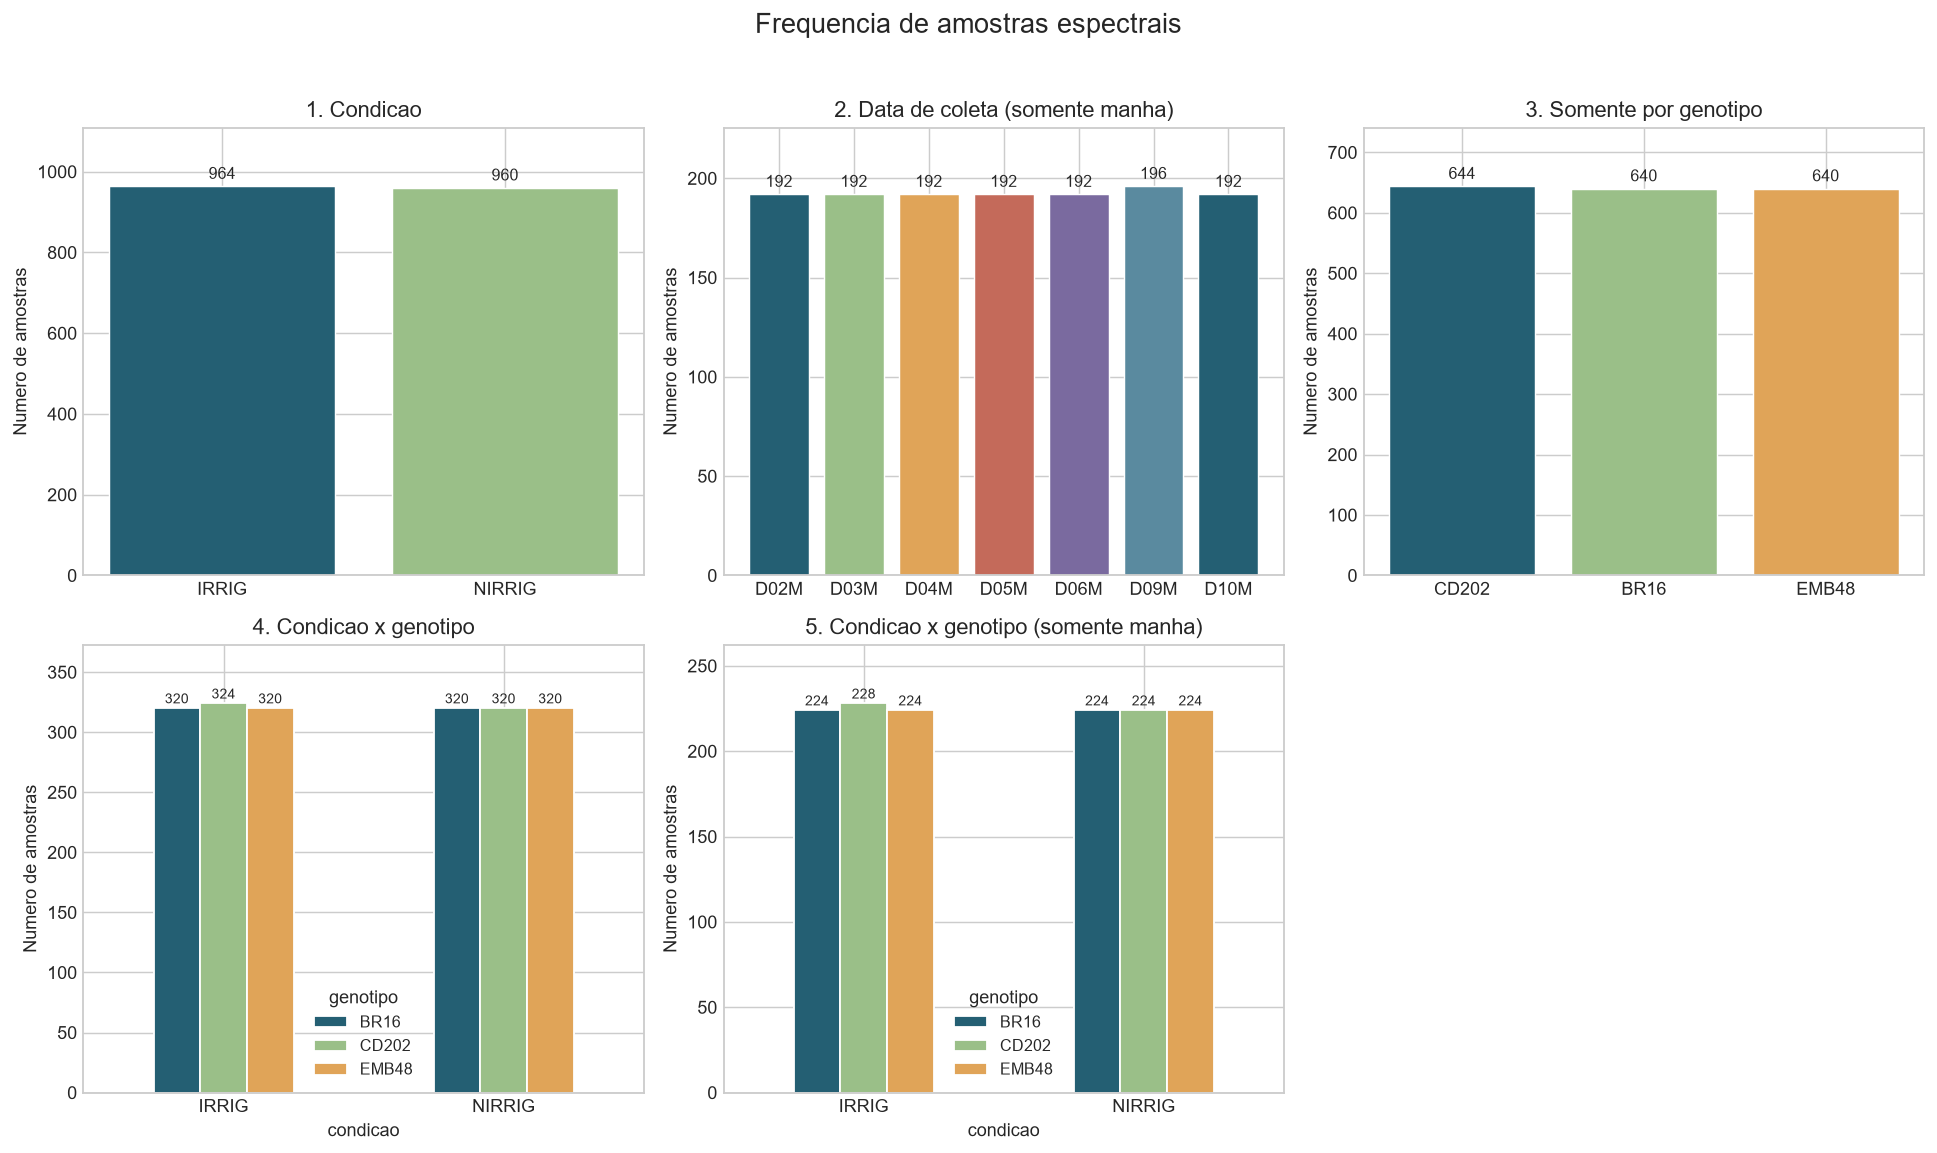

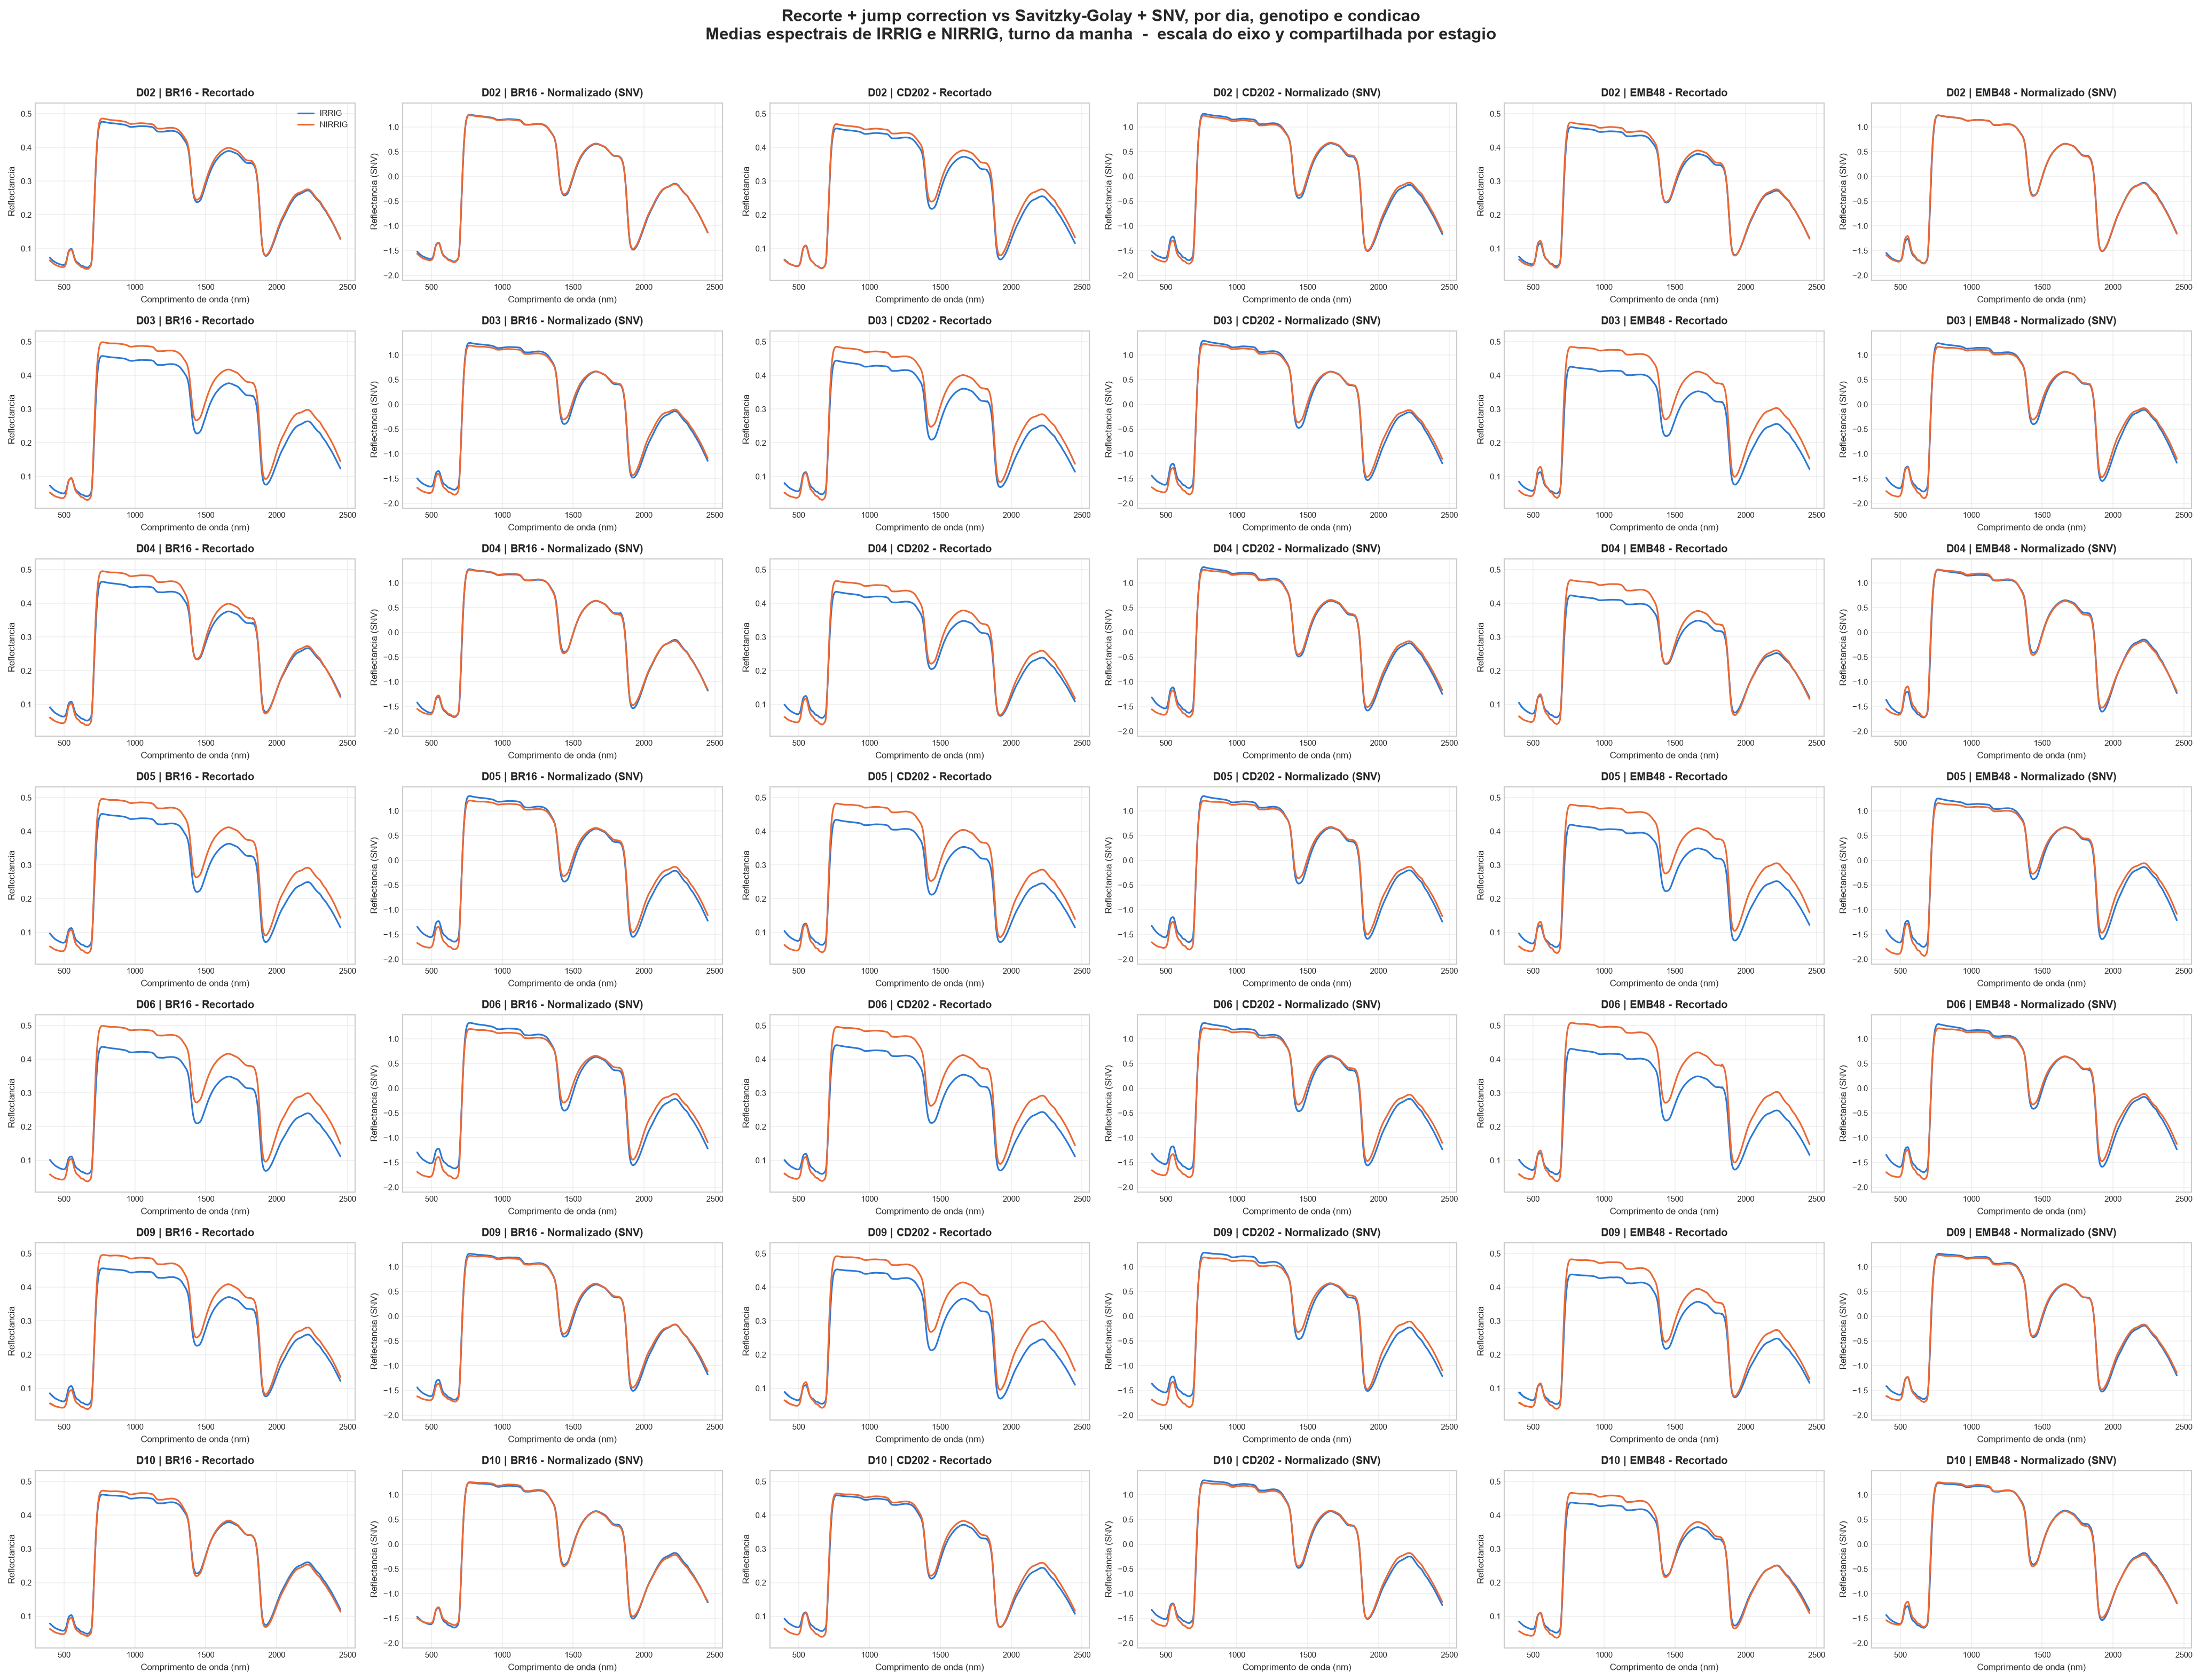

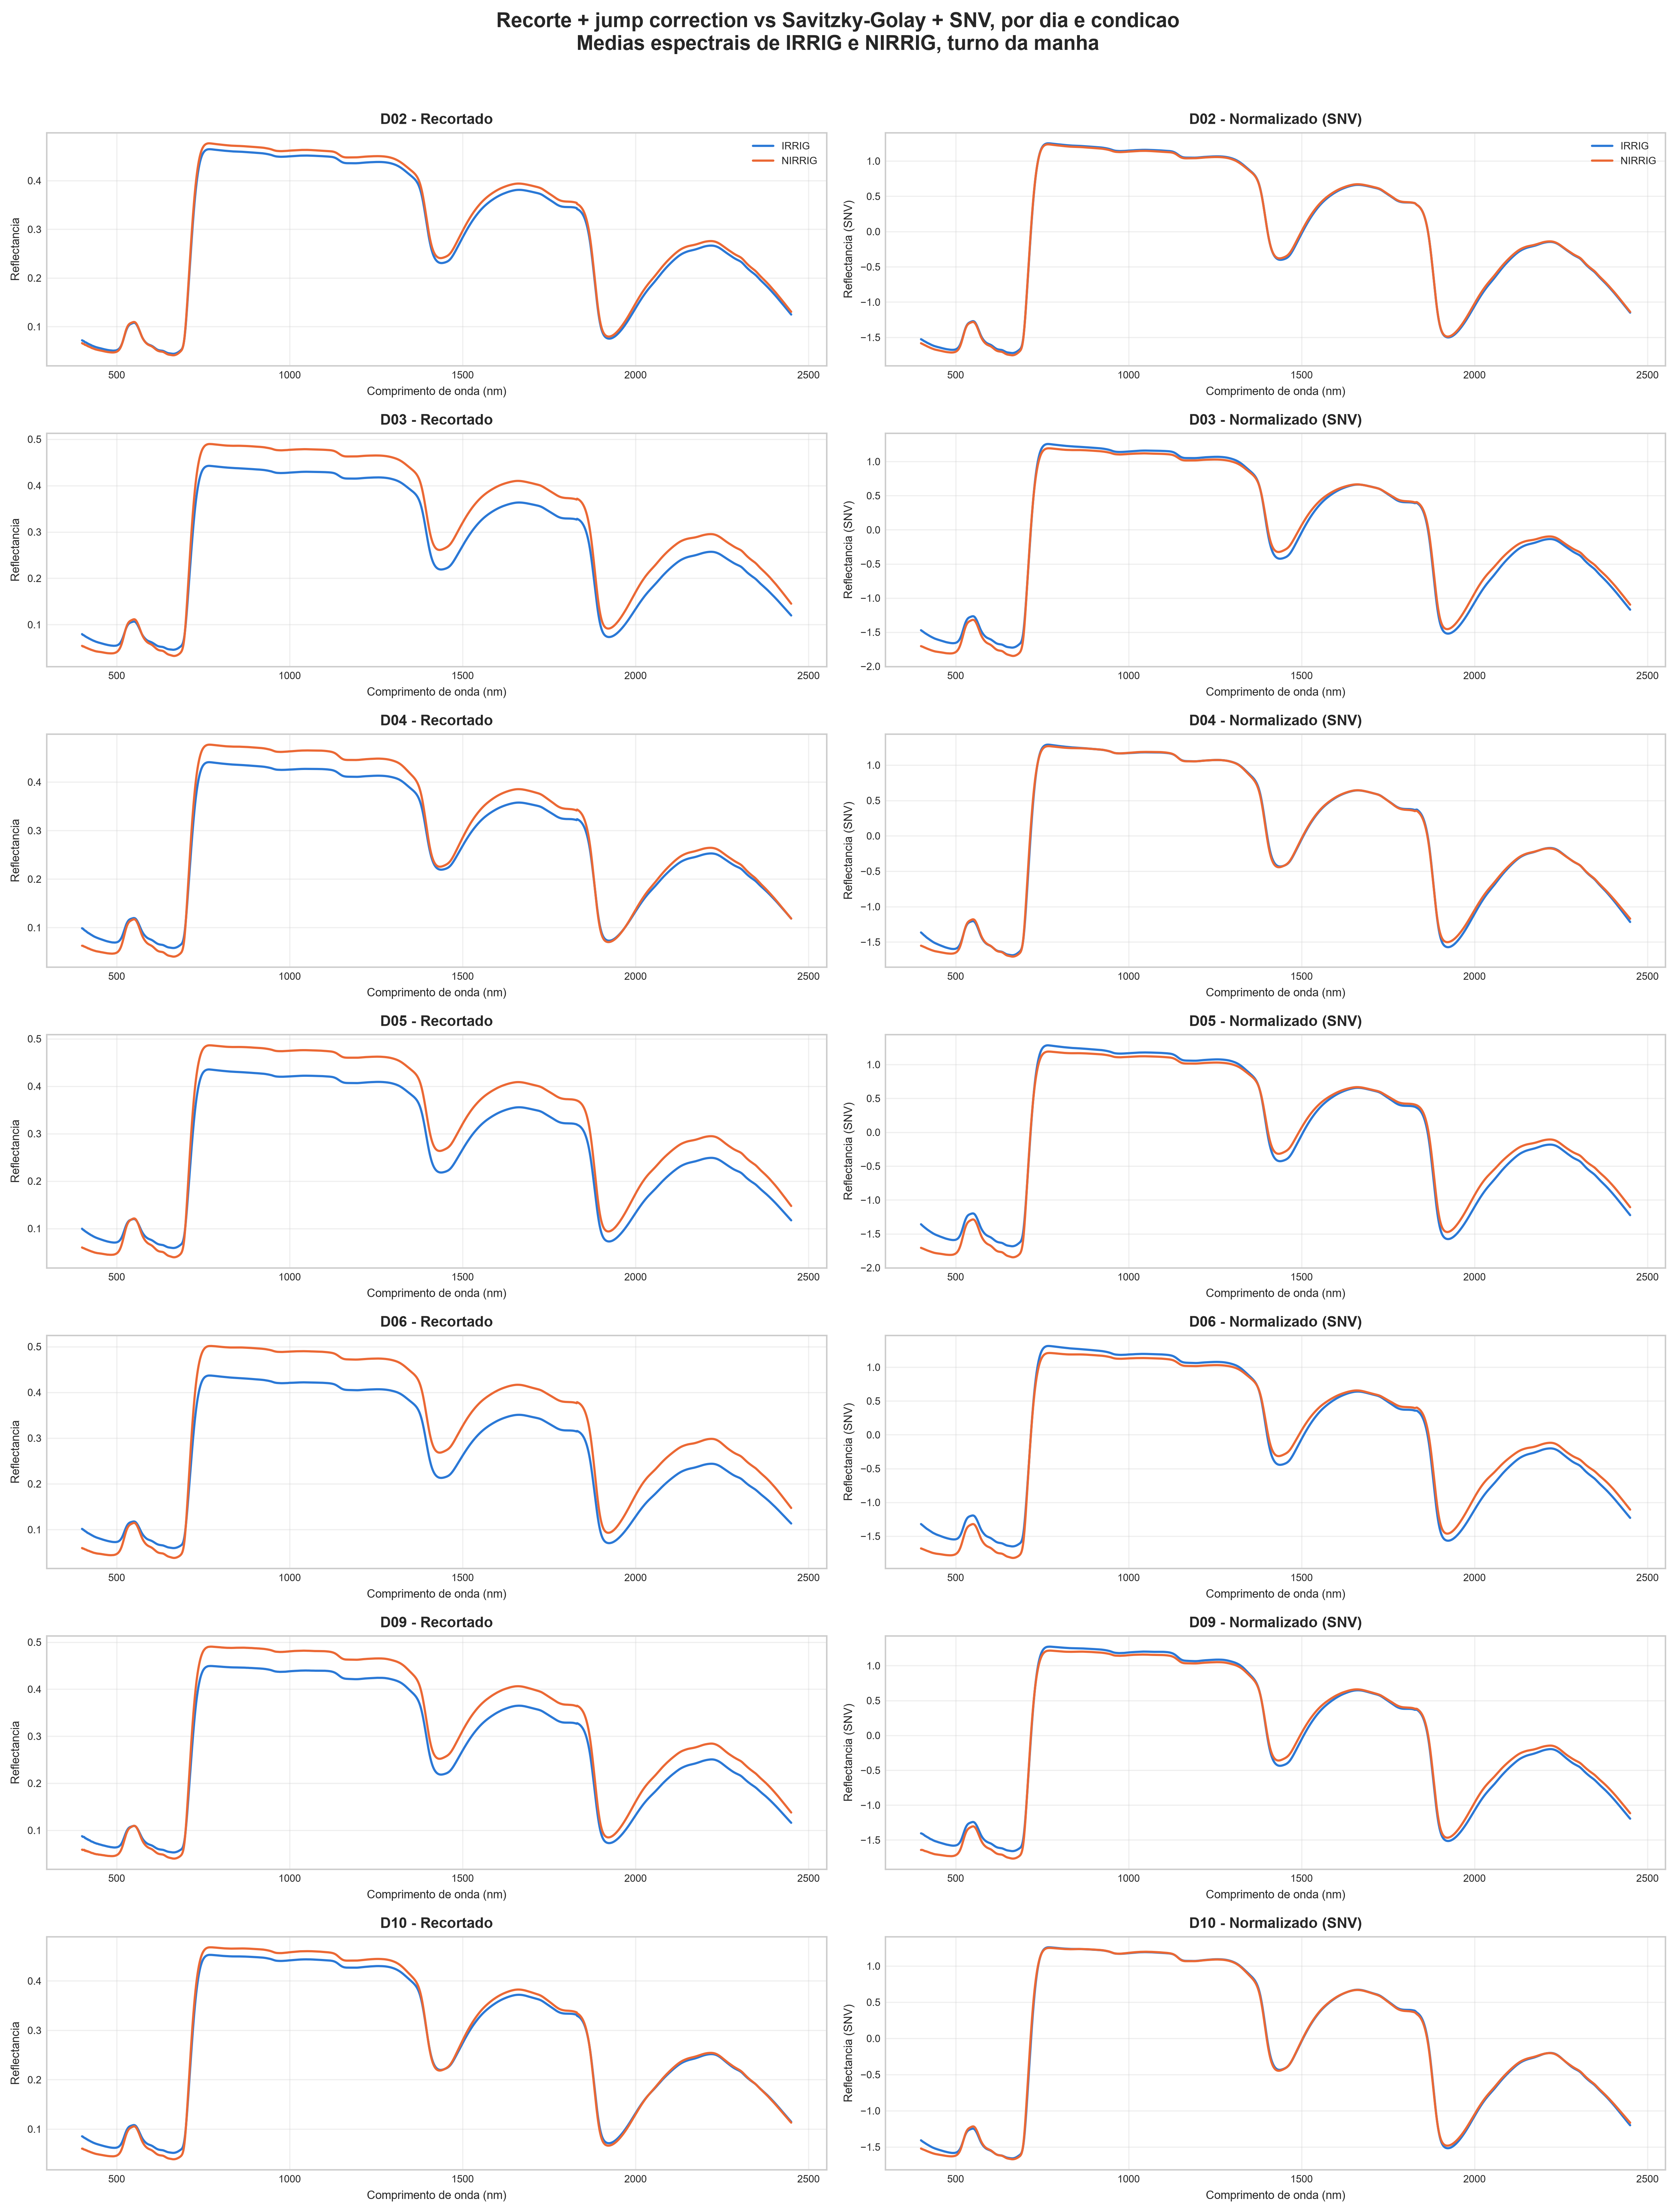

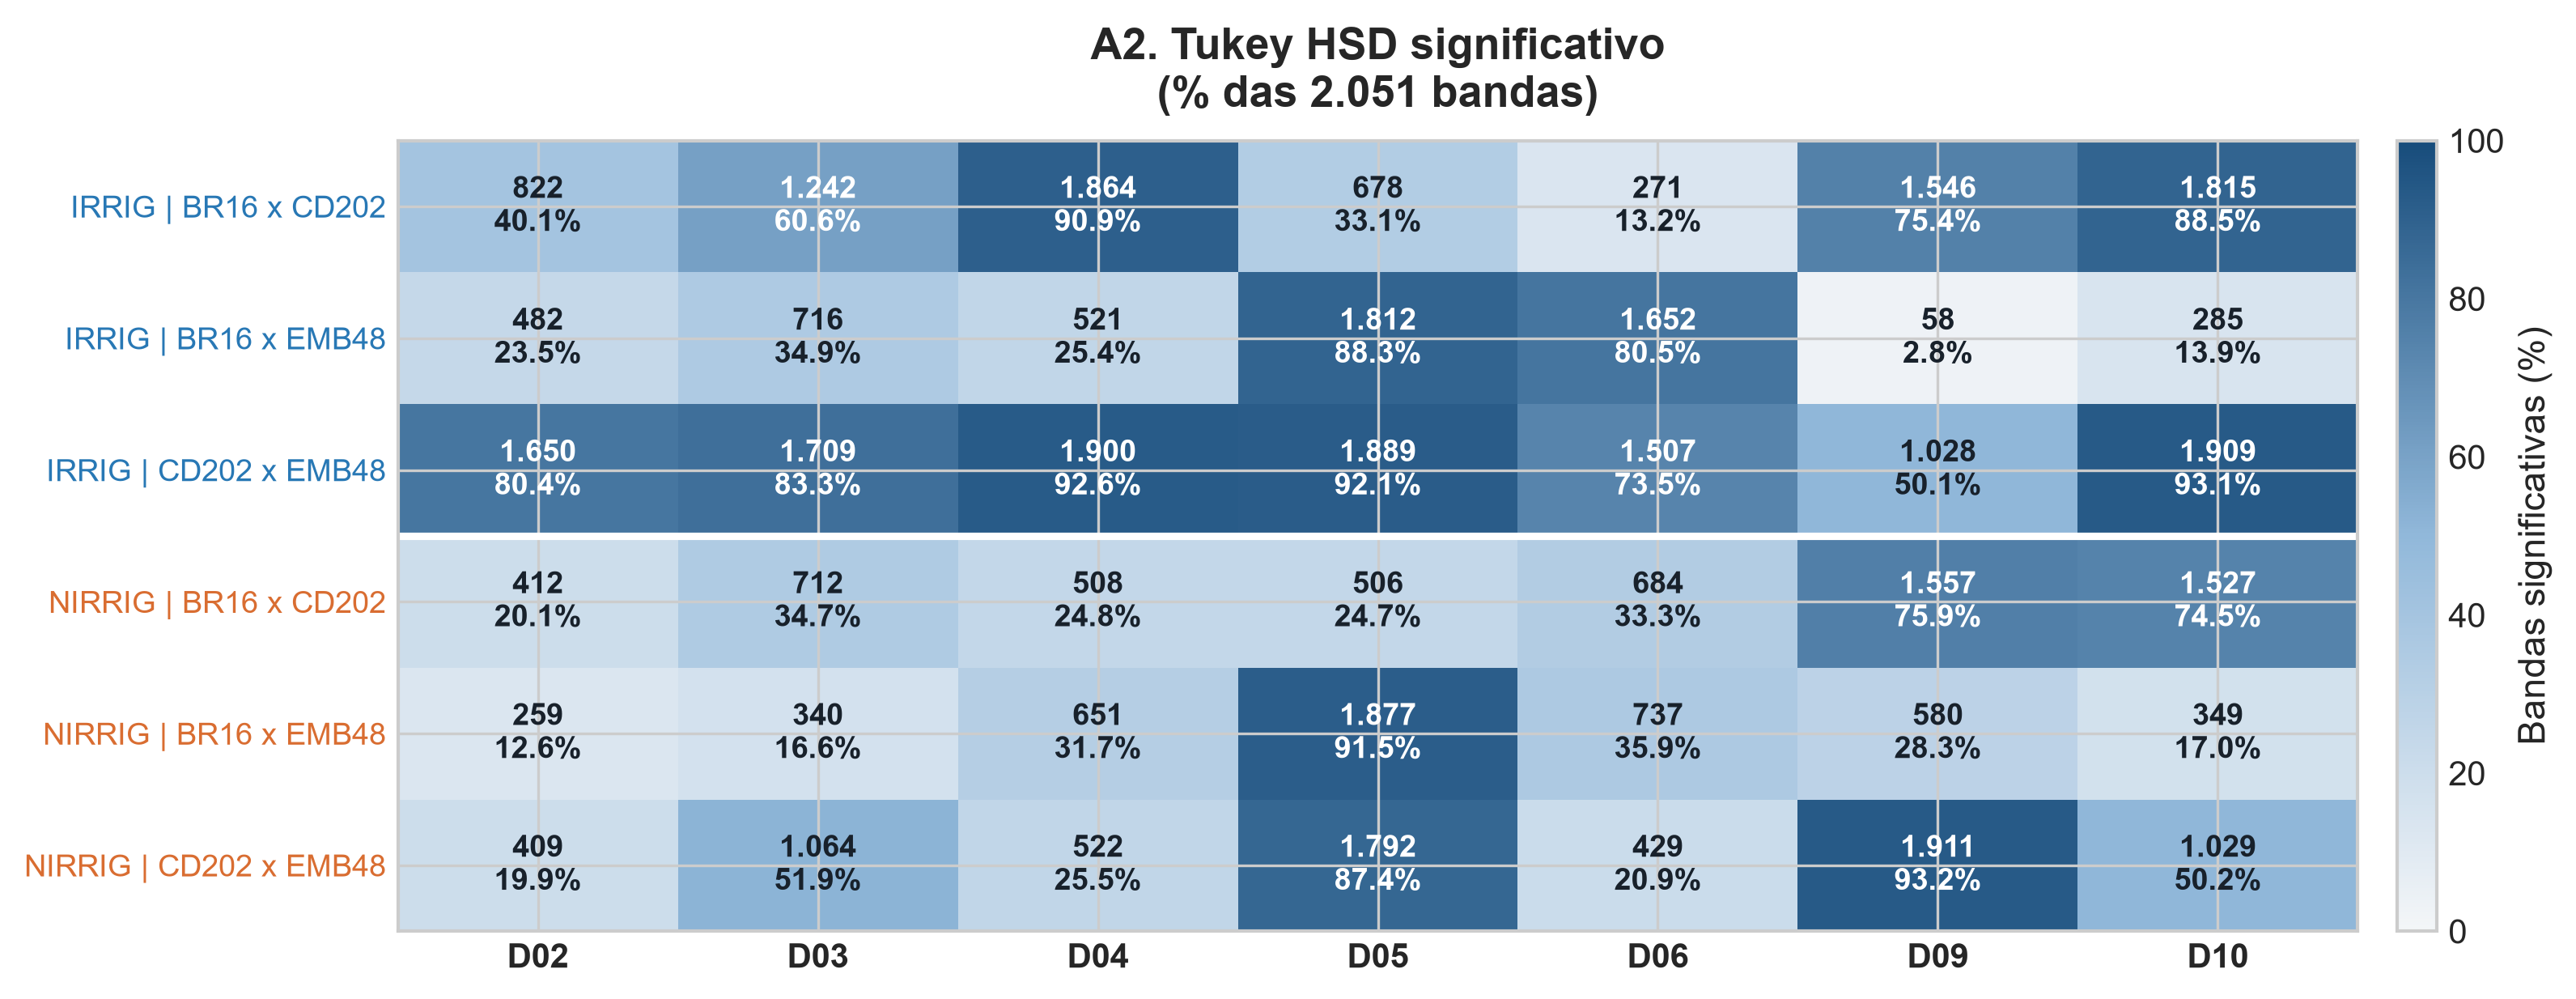

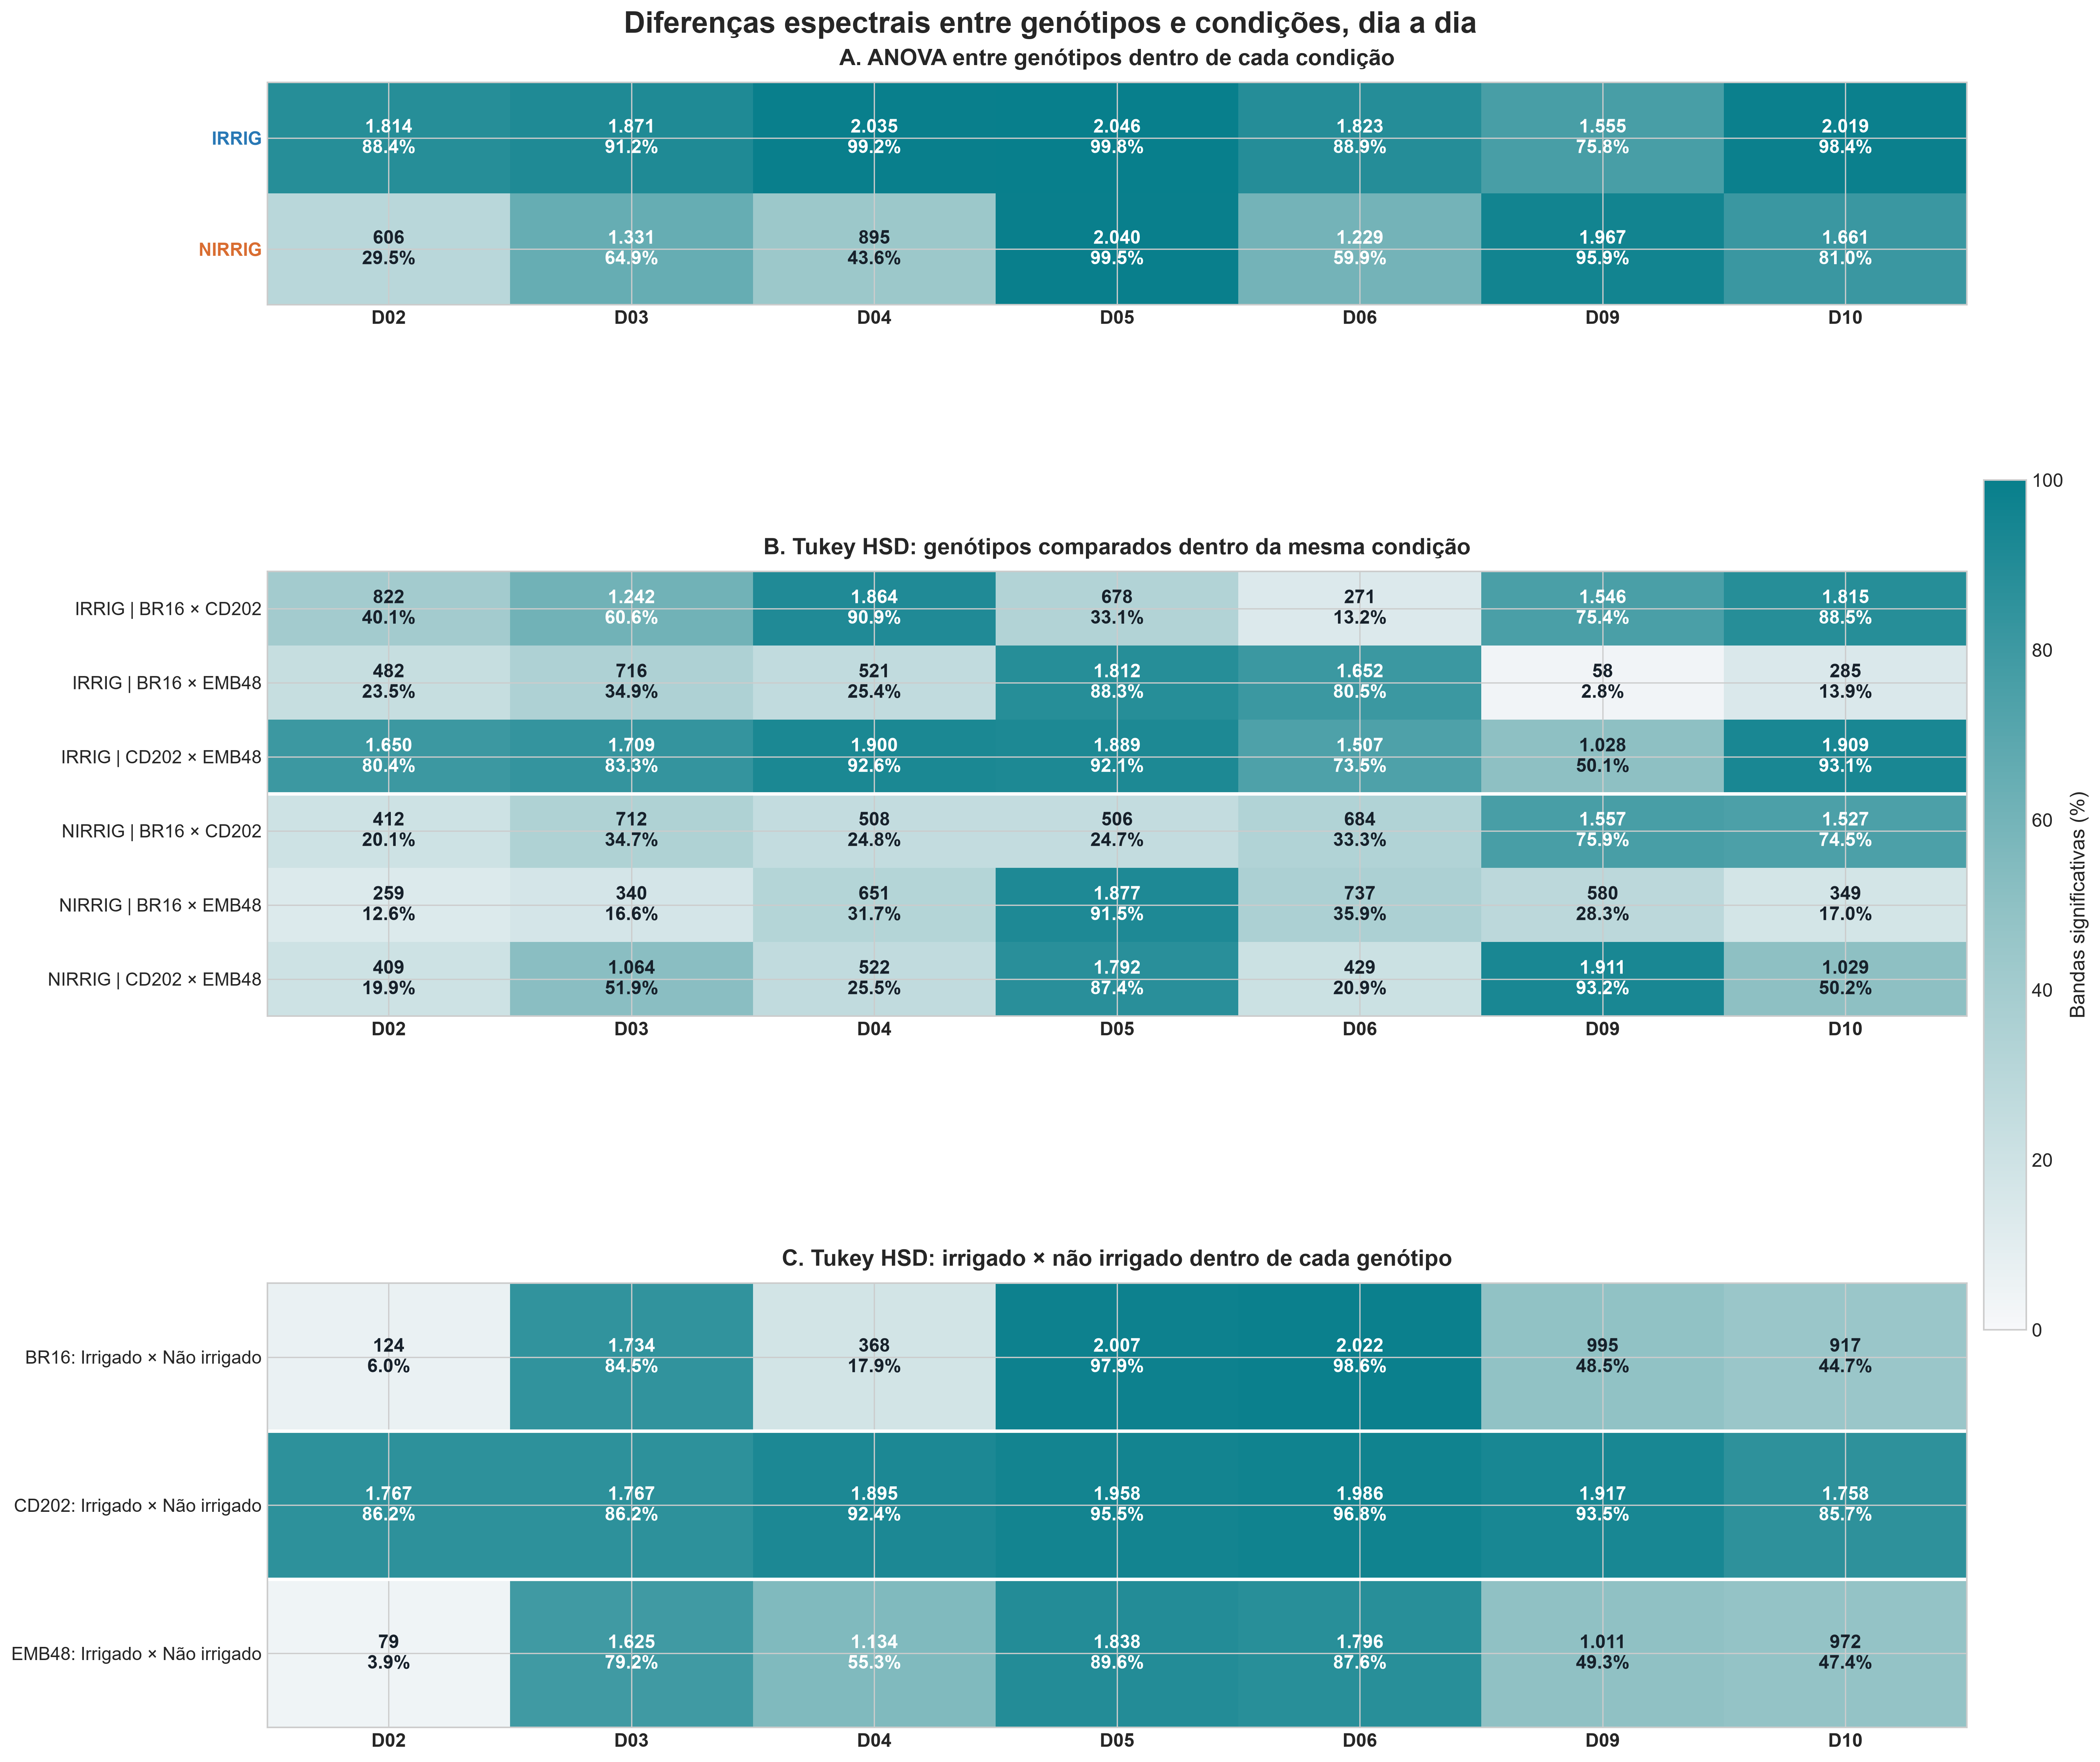

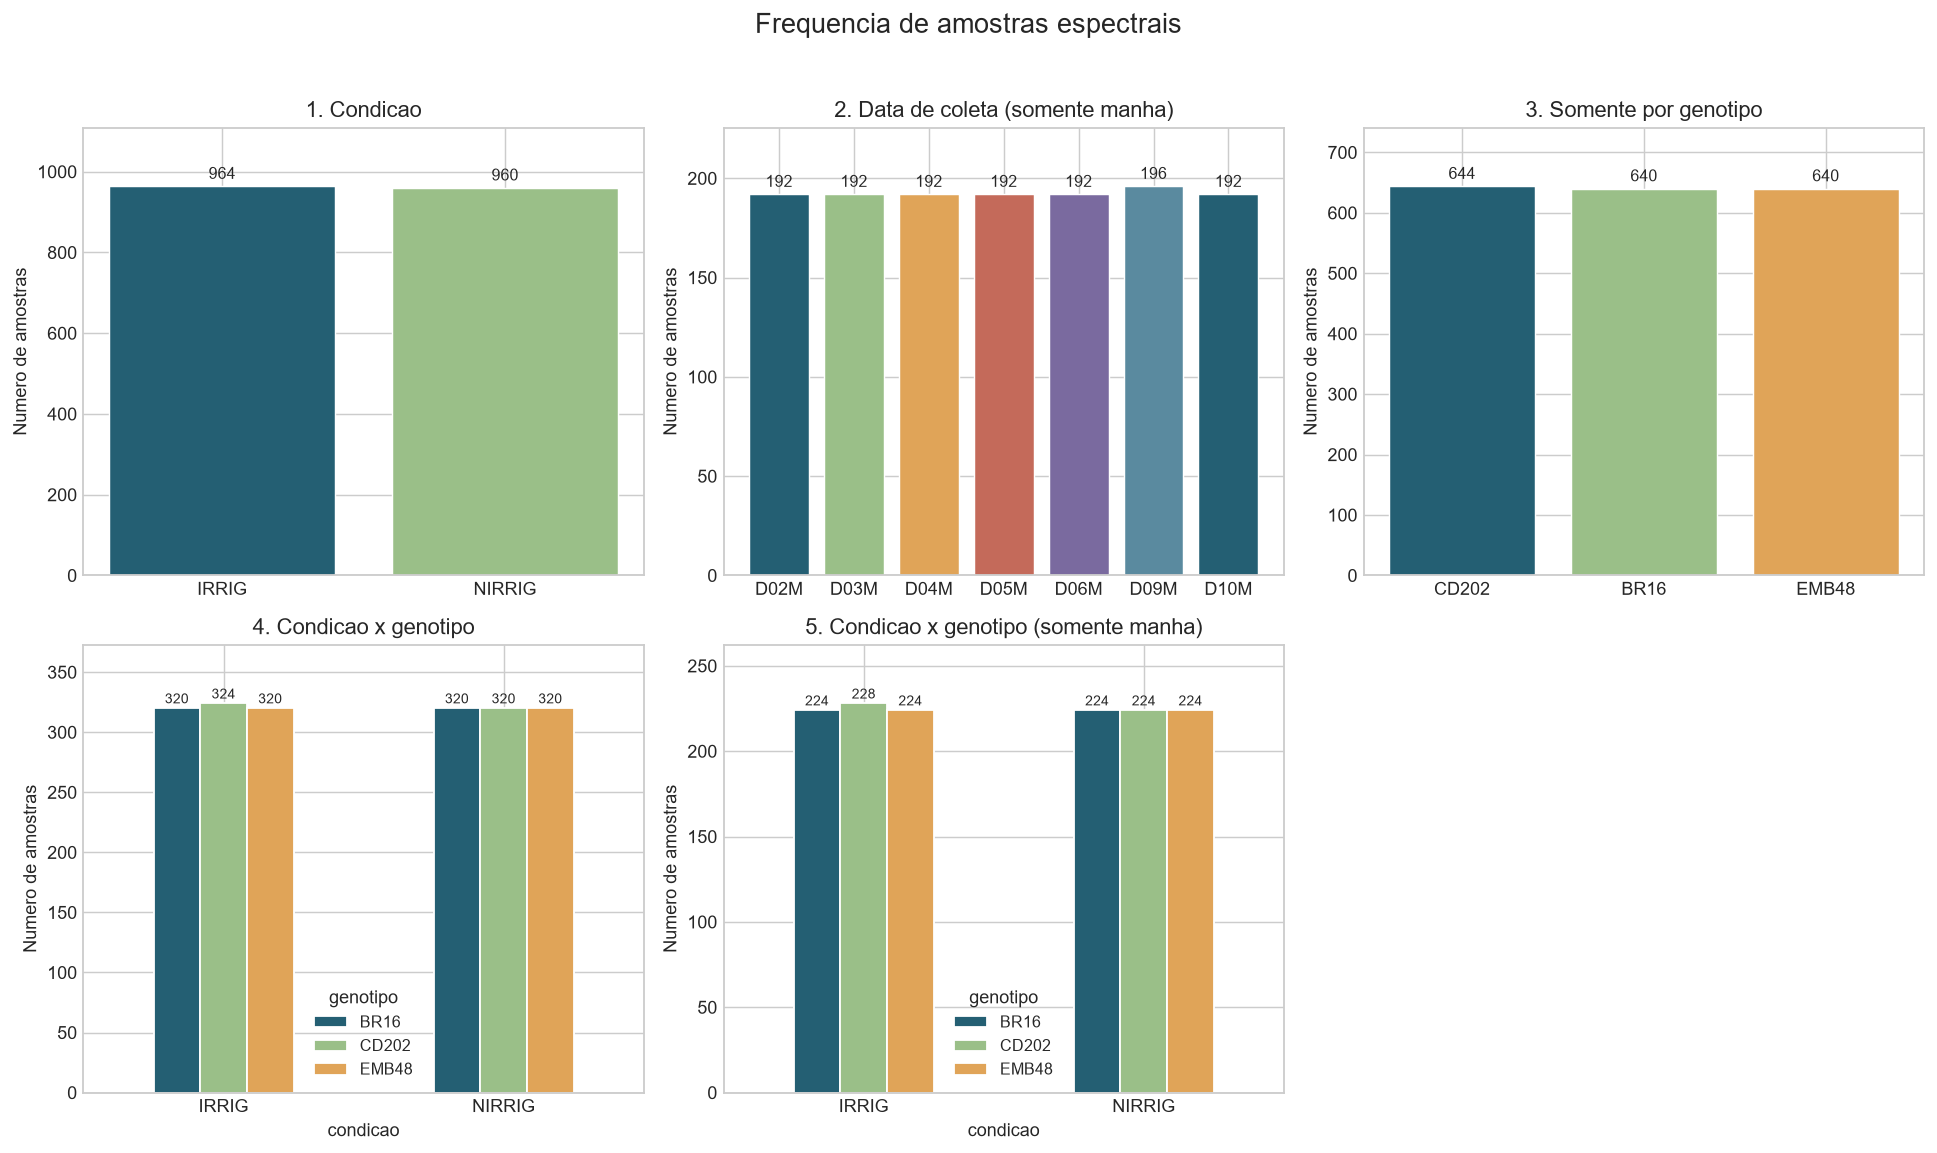

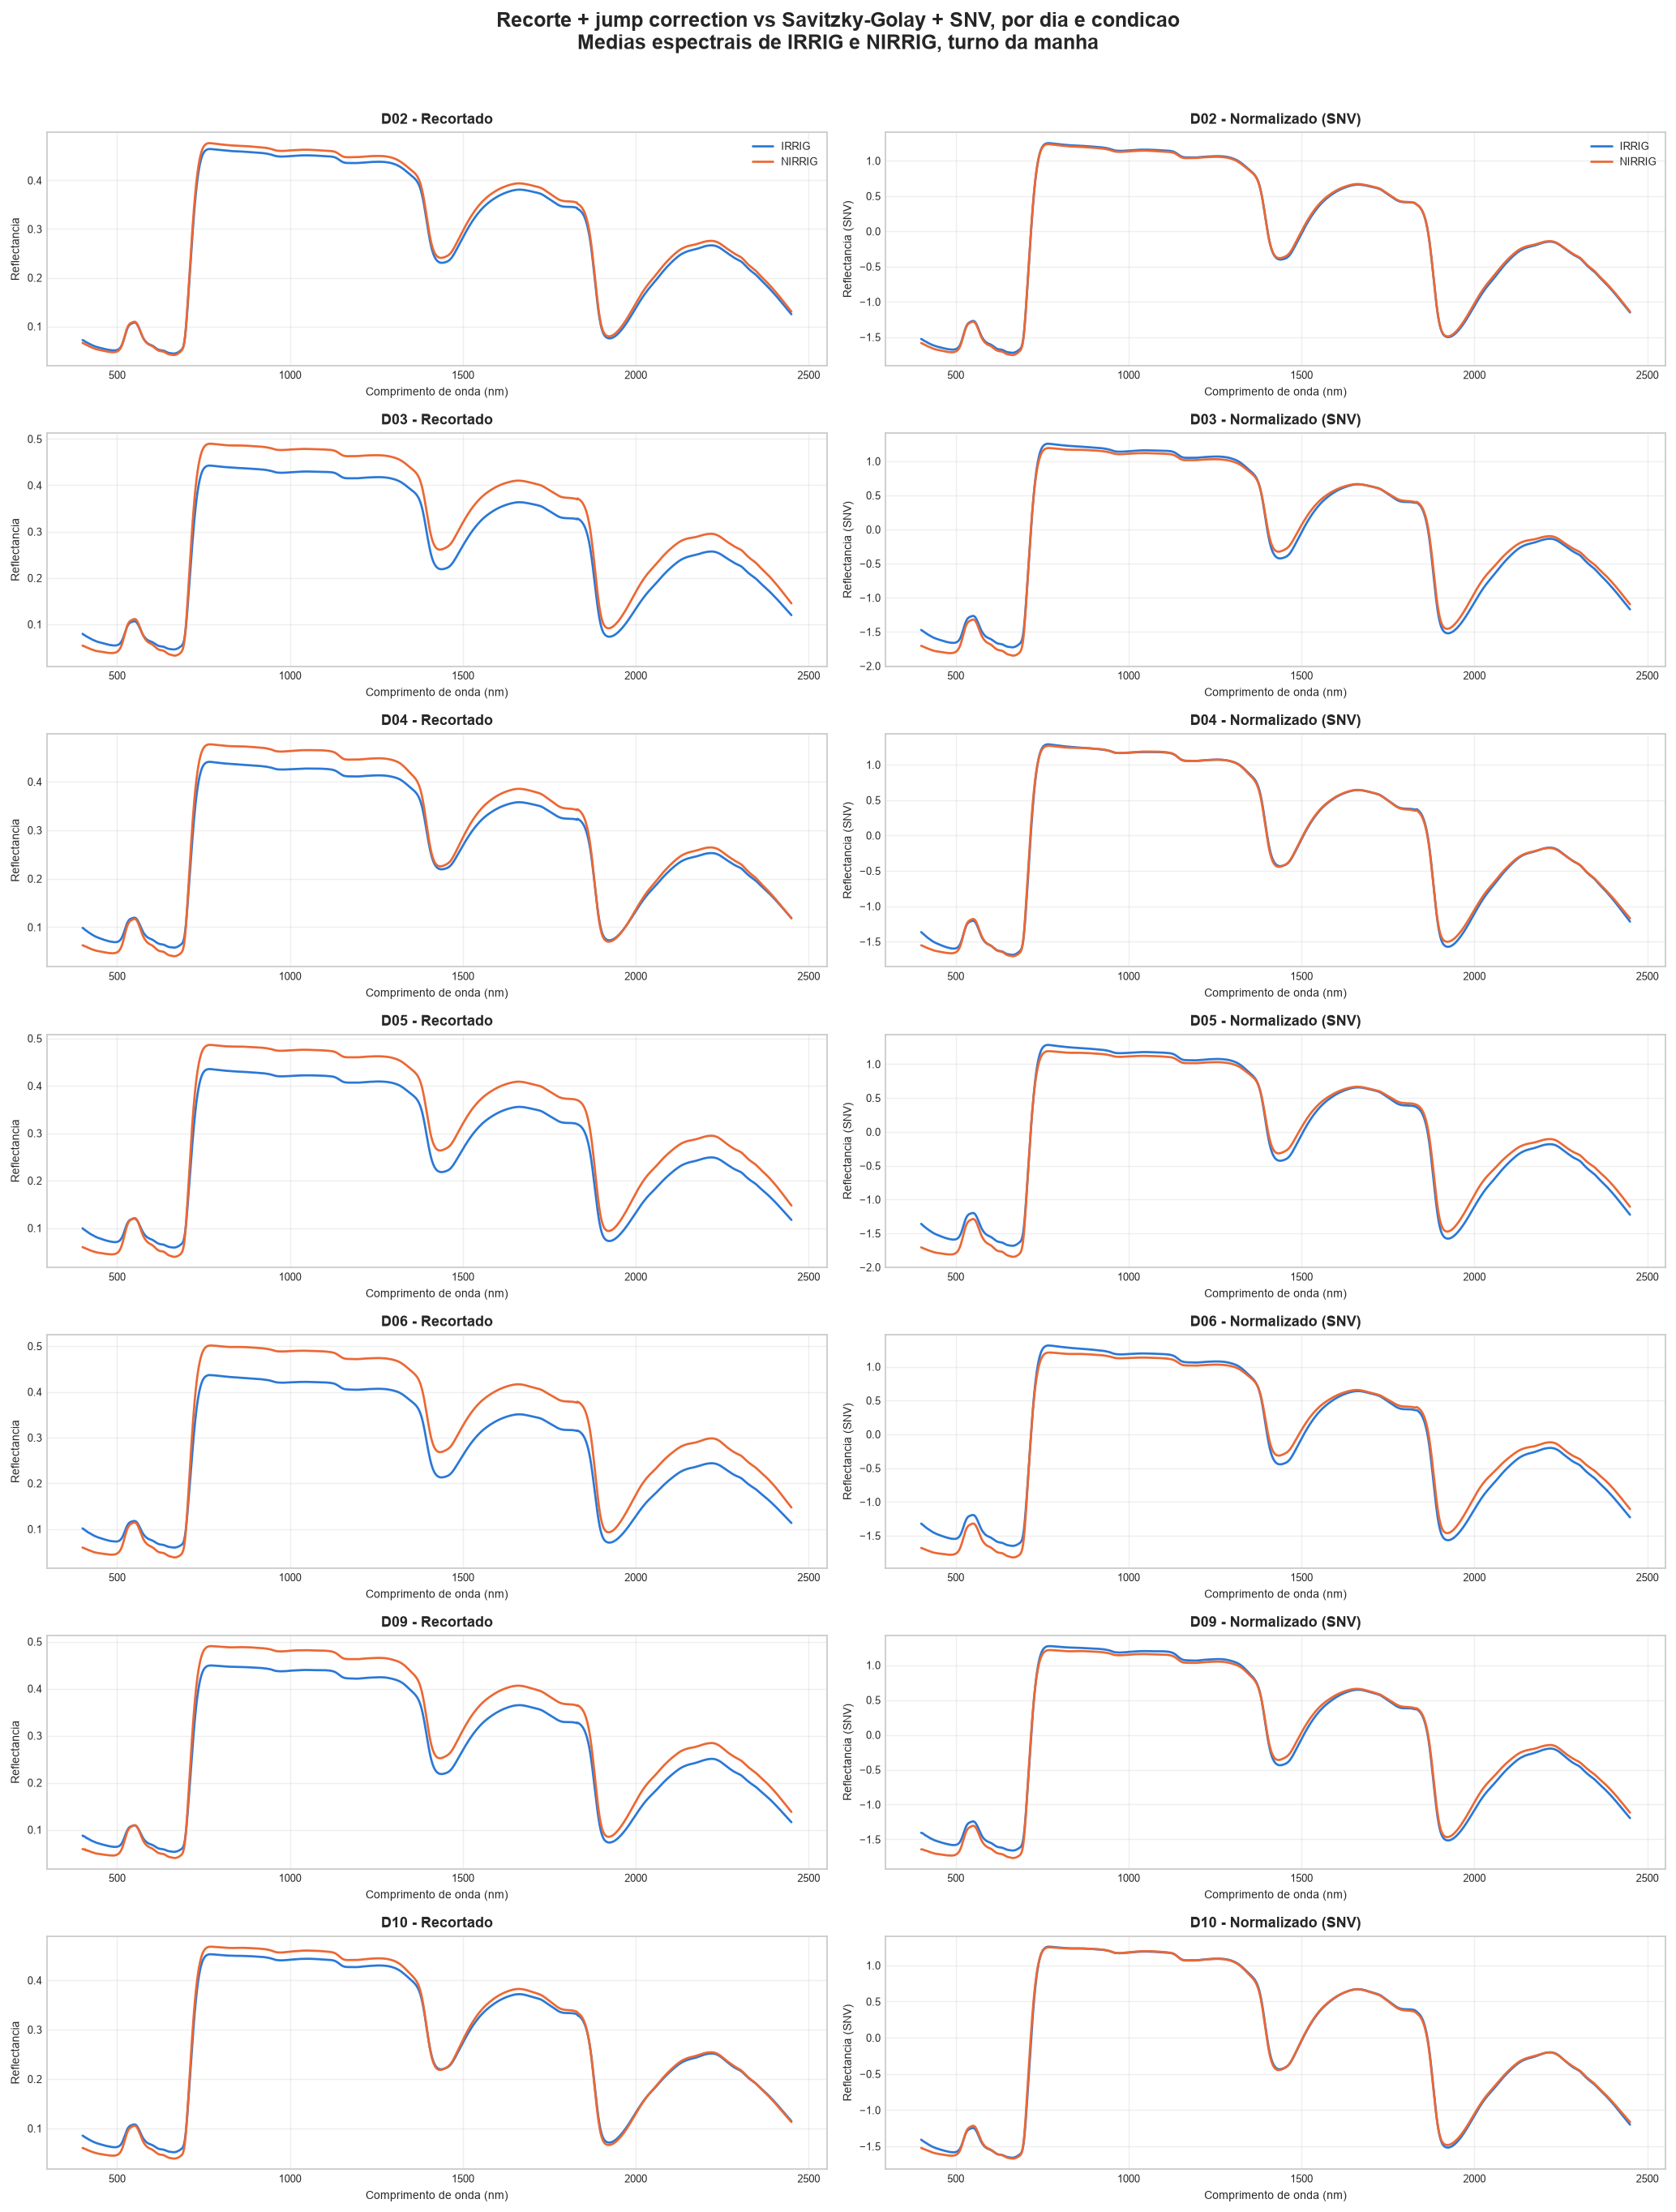

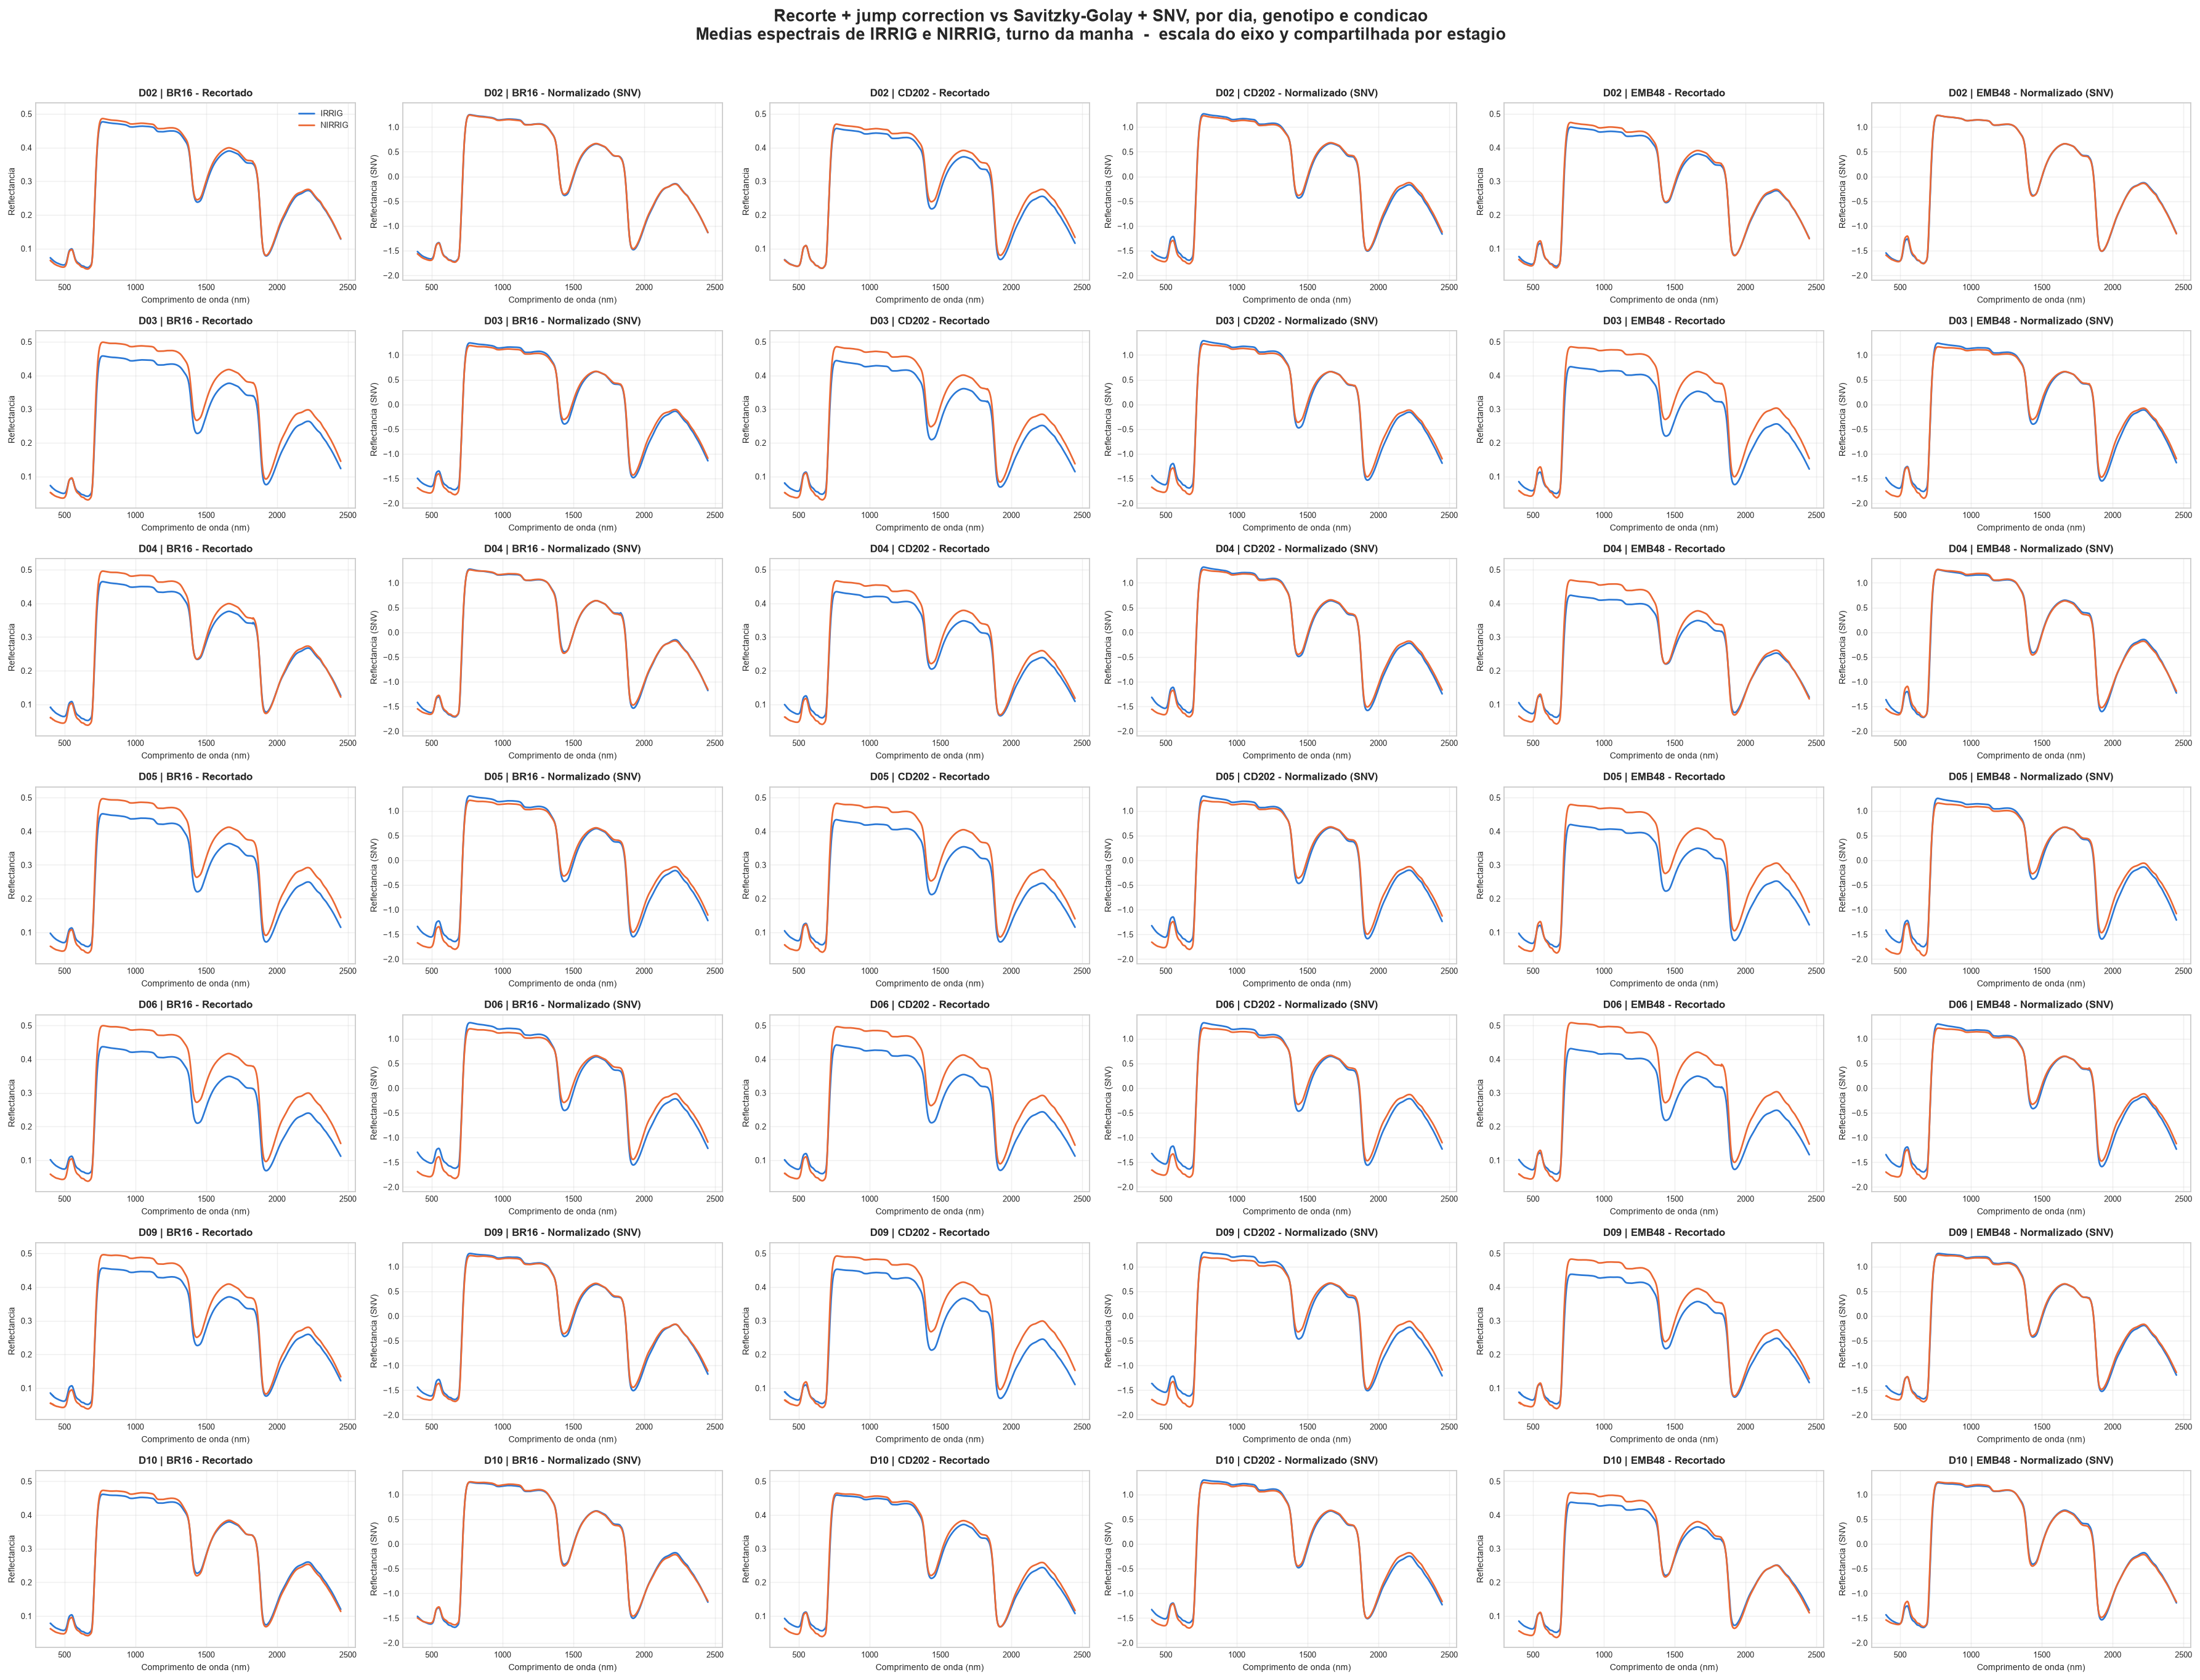

In [9]:
diferencas = pd.read_csv(
    diferencas_significativas.SAIDA_DIR / "diferencas_resumo.csv", sep=";"
)
colunas_resumo = [
    "dia", "n_amostras", "bandas", "via_anova", "via_kruskal",
    "sig_genotipo", "sig_condicao", "sig_interacao", "sig_omnibus",
    "pares_dunn_sig",
]
display(diferencas[colunas_resumo].fillna("não aplicável"))

# Reutiliza os scripts de visualização já consolidados no repositório.
executar(
    "Gráfico de frequência",
    lambda: runpy.run_path(
        str(ROOT / "coleta_dados_espectrais/grafico_frequencia_geral.py"),
        run_name="__main__",
    ),
)
executar("Assinaturas espectrais médias por dia", plot_preprocessamento.main)
executar("Assinaturas espectrais médias por genótipo", plot_preprocessamento_genotipo.main)
executar("Heatmap do efeito do genótipo", plot_heatmap_tukey_genotipos.gerar)
executar("Heatmaps dos efeitos de genótipo e condição", plot_heatmaps_anova_tukey_completo.gerar)

graficos_origem = [
    ROOT / "coleta_dados_espectrais/graficos_frequencia/frequencias_geral.png",
    plot_preprocessamento_genotipo.SAIDA,
    plot_preprocessamento.SAIDA,
    plot_heatmap_tukey_genotipos.SAIDA_PNG,
    plot_heatmaps_anova_tukey_completo.SAIDA_PNG,
]
OUTPUTS = ROOT / "script_final/outputs"
graficos_publicados = []
for origem in graficos_origem:
    destino = OUTPUTS / origem.relative_to(ROOT)
    destino.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(origem, destino)
    graficos_publicados.append(destino)
    display(Image(filename=str(destino)))

## 5. Análise temporal das bandas

> **Placeholder — não executado nesta versão.** Integrar a análise de medidas repetidas/blocos temporais após a consolidação final desta etapa.

## 6. Redução de colinearidade

Redução independente por genótipo sobre o espectro normalizado da manhã, agrupando bandas contíguas por correlação de Spearman (`|r| > 0,80`, janela de 10 nm) e mantendo uma banda representativa por grupo.

In [10]:
executar("Redução de colinearidade", reducao_colinearidade.main, "normalizado")

✓ Redução de colinearidade concluída em 7.0 s


In [11]:
resumo_colinearidade = pd.read_csv(
    reducao_colinearidade.SAIDA_DIR / "colinearidade_resumo.csv", sep=";"
)
resumo_colinearidade_exibicao = resumo_colinearidade[[
    "genotipo", "amostras", "bandas", "grupos", "reducao",
    "limiar_r", "janela_nm", "criterio_representante",
]].copy()
resumo_colinearidade_exibicao["reducao"] = (
    100 * resumo_colinearidade_exibicao["reducao"]
).round(1).astype(str) + "%"
display(resumo_colinearidade_exibicao)

,genotipo,amostras,bandas,grupos,reducao,limiar_r,janela_nm,criterio_representante
0,BR16,448,2051,206,90.0%,0.8,10.0,menor_q_condicao
1,CD202,452,2051,206,90.0%,0.8,10.0,menor_q_condicao
2,EMB48,448,2051,206,90.0%,0.8,10.0,menor_q_condicao


## 7. Seleção de variáveis

Seleção independente por genótipo entre as bandas representativas. O Top‑5 segue o script consolidado: bandas com `p ≤ 0,05`, ordenadas pelo menor p-valor; VIP e Boruta são apresentados como diagnósticos complementares.

In [12]:
executar("Seleção de variáveis", selecao_variaveis.main, "normalizado")

✓ Seleção de variáveis concluída em 95.5 s


In [13]:
top5_bandas = pd.read_csv(
    selecao_variaveis.SAIDA_DIR / "top5_bandas_por_genotipo.csv", sep=";"
)
colunas_top5 = [
    "genotipo", "posicao", "banda_nm", "p_condicao", "q_condicao",
    "vip", "vip_acima_de_1", "decisao_boruta", "confirmada_boruta",
]
display(top5_bandas[colunas_top5].sort_values(["genotipo", "posicao"]))

,genotipo,posicao,banda_nm,p_condicao,q_condicao,vip,vip_acima_de_1,decisao_boruta,confirmada_boruta
0,BR16,1,403,6.211923e-12,1.166727e-11,1.412480,True,confirmada,True
1,BR16,2,414,6.211923e-12,1.166727e-11,1.287982,True,confirmada,True
2,BR16,3,425,6.211923e-12,1.166727e-11,1.187183,True,confirmada,True
3,BR16,4,434,6.211923e-12,1.166727e-11,1.116374,True,confirmada,True
4,BR16,5,445,6.211923e-12,1.166727e-11,1.033733,True,confirmada,True
5,CD202,1,403,1.470814e-12,4.986331e-12,1.305052,True,confirmada,True
6,CD202,2,415,1.470814e-12,4.986331e-12,1.224070,True,confirmada,True
7,CD202,3,425,1.470814e-12,4.986331e-12,1.172833,True,confirmada,True
8,CD202,4,434,1.470814e-12,4.986331e-12,1.115225,True,confirmada,True
9,CD202,5,445,1.470814e-12,4.986331e-12,1.064562,True,confirmada,True


## 8. Classificação

Classificação de IRRIG × NIRRIG nos cenários agrupado e por genótipo, usando Random Forest, Gradient Boosting, SVM e PLS‑DA com `StratifiedGroupKFold` de cinco dobras agrupadas por nomenclatura.

In [14]:
executar(
    "Classificação agrupada e por genótipo",
    classificacao_pipeline.main,
    "--modo", "ambos", "--estagio", "normalizado",
)

✓ Classificação agrupada e por genótipo concluída em 68.8 s


In [15]:
modelos_classificacao = ("random_forest", "gradient_boosting", "svm", "pls_da")
cenarios_classificacao = [("agrupado", "todos"), *(
    ("por_genotipo", genotipo) for genotipo in ("BR16", "CD202", "EMB48")
)]
resumos_classificacao = []
for modo, genotipo in cenarios_classificacao:
    base = ROOT / "classificacao" / "outputs" / modo
    if modo == "por_genotipo":
        base = base / genotipo
    for modelo in modelos_classificacao:
        resumos_classificacao.append(
            pd.read_csv(base / modelo / "metricas_resumo.csv", sep=";")
        )

resumo_classificacao = pd.concat(resumos_classificacao, ignore_index=True)
metricas_exibicao = [
    "modelo", "modo", "genotipo", "accuracy_media", "precision_media",
    "recall_media", "f1_score_media", "kappa_media", "auc_roc_media",
]
display(resumo_classificacao[metricas_exibicao].round(4))

,modelo,modo,genotipo,accuracy_media,precision_media,recall_media,f1_score_media,kappa_media,auc_roc_media
0,random_forest,agrupado,todos,0.8858,0.8736,0.9019,0.8872,0.7716,0.9576
1,gradient_boosting,agrupado,todos,0.8776,0.8611,0.9004,0.8801,0.7553,0.9546
2,svm,agrupado,todos,0.8702,0.8285,0.9331,0.8777,0.7406,0.9485
3,pls_da,agrupado,todos,0.8776,0.8134,0.9807,0.8891,0.7554,0.9544
4,random_forest,por_genotipo,BR16,0.8416,0.8474,0.8395,0.8410,0.6833,0.9329
5,gradient_boosting,por_genotipo,BR16,0.8215,0.8165,0.8400,0.8248,0.6435,0.9265
6,svm,por_genotipo,BR16,0.7678,0.7372,0.8400,0.7828,0.5361,0.9075
7,pls_da,por_genotipo,BR16,0.8282,0.7604,0.9644,0.8494,0.6565,0.9314
8,random_forest,por_genotipo,CD202,0.9403,0.9422,0.9376,0.9398,0.8806,0.9889
9,gradient_boosting,por_genotipo,CD202,0.9226,0.9285,0.9152,0.9214,0.8452,0.9843


## 9. Desenvolvimento de novo Índice Espectral

> **Placeholder — não executado nesta versão.** Integrar a construção e avaliação do novo índice depois da seleção e validação das bandas finais.

## Validação da execução

Verificações mínimas dos contratos entre as etapas já consolidadas.

In [16]:
genotipos_esperados = {"BR16", "CD202", "EMB48"}
arquivos_colinearidade = [
    reducao_colinearidade.SAIDA_DIR / genotipo / arquivo
    for genotipo in sorted(genotipos_esperados)
    for arquivo in ("grupos_colinearidade.csv", "bandas_representativas.csv", "colinearidade_resumo.csv")
]
arquivos_selecao = [
    selecao_variaveis.SAIDA_DIR / genotipo / arquivo
    for genotipo in sorted(genotipos_esperados)
    for arquivo in ("pls_da_validacao.csv", "vip_pls_da.csv", "boruta_resultado.csv", "selecao_variaveis.csv", "top5_bandas.csv")
]
arquivos_classificacao = [
    (ROOT / "classificacao" / "outputs" / modo / (genotipo if modo == "por_genotipo" else "") / modelo / arquivo)
    for modo, genotipo in cenarios_classificacao
    for modelo in modelos_classificacao
    for arquivo in ("metricas_folds.csv", "metricas_resumo.csv")
]

saidas_obrigatorias = [
    limpar_metadados.SAIDA,
    *arquivos_preprocessamento.values(),
    shapiro_normalidade.SAIDA_DIR / "normalidade_resumo.csv",
    shapiro_normalidade.SAIDA_DIR / "normalidade_por_banda.csv",
    diferencas_significativas.SAIDA_DIR / "diferencas_resumo.csv",
    diferencas_significativas.SAIDA_DIR / "diferencas_por_banda_dia.csv",
    reducao_colinearidade.SAIDA_DIR / "colinearidade_resumo.csv",
    selecao_variaveis.SAIDA_DIR / "top5_bandas_por_genotipo.csv",
    *arquivos_colinearidade,
    *arquivos_selecao,
    *arquivos_classificacao,
    *graficos_publicados,
]

assert all(arquivo.exists() for arquivo in saidas_obrigatorias), "Há saídas obrigatórias ausentes."
assert set(resumo_preprocessamento["bandas"]) == {2051}, "Quantidade inesperada de bandas."
assert set(resumo_preprocessamento["faixa_nm"]) == {"400–2450"}, "Faixa espectral inesperada."
assert set(normalidade["agrupamento"]) == {
    "global", "genotipo", "condicao", "dia", "genotipo_condicao_dia"
}, "Agrupamentos de normalidade incompletos."
assert set(diferencas["dia"]) == {"D02", "D03", "D04", "D05", "D06", "D09", "D10"}, (
    "Dias ausentes no resumo de diferenças."
)
assert set(resumo_colinearidade["genotipo"]) == genotipos_esperados, "Genótipos ausentes na redução."
assert resumo_colinearidade["bandas"].eq(2051).all(), "Entrada inesperada na redução."
assert (resumo_colinearidade["grupos"] < resumo_colinearidade["bandas"]).all(), "Não houve redução de colinearidade."
assert set(top5_bandas["genotipo"]) == genotipos_esperados, "Genótipos ausentes na seleção."
assert top5_bandas.groupby("genotipo").size().eq(5).all(), "A seleção não retornou cinco bandas por genótipo."
for genotipo in genotipos_esperados:
    representantes = pd.read_csv(
        reducao_colinearidade.SAIDA_DIR / genotipo / "bandas_representativas.csv", sep=";"
    )["banda_representante_nm"].astype(int)
    selecionadas = top5_bandas.loc[top5_bandas["genotipo"] == genotipo, "banda_nm"].astype(int)
    assert set(selecionadas).issubset(set(representantes)), f"Top-5 de {genotipo} fora das representantes."
assert len(resumo_classificacao) == 16, "Quantidade inesperada de resultados de classificação."
assert set(resumo_classificacao["modelo"]) == set(modelos_classificacao), "Modelos de classificação incompletos."
assert resumo_classificacao[metricas_exibicao[3:]].apply(
    pd.to_numeric, errors="coerce"
).notna().all().all(), "Há métricas de classificação inválidas."
for arquivo in arquivos_classificacao[::2]:
    assert pd.read_csv(arquivo, sep=";")["fold"].nunique() == 5, f"Validação incompleta em {arquivo}."

display(pd.DataFrame({
    "verificação": ["artefatos", "bandas", "faixa espectral", "normalidade", "diferenças", "colinearidade", "seleção", "classificação"],
    "resultado": ["OK", "2.051", "400–2450 nm", "5 agrupamentos", "7 dias", "3 genótipos", "Top-5 por genótipo", "16 resultados / 5 folds"],
}))

,verificação,resultado
0,artefatos,OK
1,bandas,2.051
2,faixa espectral,400–2450 nm
3,normalidade,5 agrupamentos
4,diferenças,7 dias
5,colinearidade,3 genótipos
6,seleção,Top-5 por genótipo
7,classificação,16 resultados / 5 folds
